# Final Project: Topic Modeling
## Executive Summary: 
In 180 to 200 words, provide an overview of the notebooks you developed. Describe the use case, data, preprocessing steps, model development, and main points of the analysis. State which model works best or that none of the models were satisfactory and provide reasons. Describe the topics and explain how the model will address the use case, or if none of the models worked well, state what the next steps should be.
## Importing the Dataset: Trip Advisor Reviews


In [1]:
import pandas as pd # data manipulation
import langdetect  # language detection
import matplotlib.pyplot  # plotting
import nltk  # natural language processing
import numpy  # arrays and matrices
import pandas  # dataframes
import pyLDAvis  # plotting
import regex  # regular expressions
import sklearn  # machine learning
import unicodedata  # unicode data manipulation
import random # random number generation

# Text preprocessing and feature extraction
from sklearn.decomposition import NMF  # NMF model
from sklearn.decomposition import LatentDirichletAllocation  # LDA model
from sklearn.feature_extraction.text import TfidfVectorizer # TF-IDF vectorizer
from nltk.stem import WordNetLemmatizer  # lemmatizer
from sklearn.feature_extraction.text import CountVectorizer  # Count vectorizer

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\danie\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\danie\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\danie\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
url = "https://raw.githubusercontent.com/Hunteracademic/Unsupervised_assignment_1/master/tripadvisor_hotel_reviews.csv"
df = pd.read_csv(url)
df.head()

c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\pandas\core\frame.py:655: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(IPython.__version__) < LooseVersion('3.0'):
c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\pandas\core\frame.py:655: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(IPython.__version__) < LooseVersion('3.0'):


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


## Preprocessing: 
Clean and prepare text for LDA and NMF topic modeling. Include steps such as case normalization, lemmatization, stop word removal, and tokenization. 

### Language Filter

In [3]:
def do_language_identifying(txt):
    try: the_language = langdetect.detect(txt)
    except: the_language = 'none'
    return the_language

df['Language'] = df['Review'].apply(do_language_identifying)
df['Language'].value_counts()

en    20475
fr        7
af        5
ro        1
ca        1
es        1
da        1
Name: Language, dtype: int64

Removing non-english reviews

In [4]:
reviews_en = df[df['Language'] == 'en']

### Tokenization / Removing Punctuation / Case Normalization

In [5]:
WORD_RE = regex.compile(r"(?V1)\p{L}+(?:[’'-]\p{L}+)*")

def tokenize_for_topics(text):
    text = unicodedata.normalize("NFKC", str(text)).lower()
    text = regex.sub(r"[‘’`´]", "'", text)      # normalize apostrophes
    text = regex.sub(r"[‐‑‒–—−]", "-", text)    # normalize dash variants
    return WORD_RE.findall(text)

reviews_en["Tokens"] = reviews_en["Review"].apply(tokenize_for_topics)

reviews_en['Tokens'][0]

c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  if __name__ == "__main__":


['nice',
 'hotel',
 'expensive',
 'parking',
 'got',
 'good',
 'deal',
 'stay',
 'hotel',
 'anniversary',
 'arrived',
 'late',
 'evening',
 'took',
 'advice',
 'previous',
 'reviews',
 'did',
 'valet',
 'parking',
 'check',
 'quick',
 'easy',
 'little',
 'disappointed',
 'non-existent',
 'view',
 'room',
 'room',
 'clean',
 'nice',
 'size',
 'bed',
 'comfortable',
 'woke',
 'stiff',
 'neck',
 'high',
 'pillows',
 'not',
 'soundproof',
 'like',
 'heard',
 'music',
 'room',
 'night',
 'morning',
 'loud',
 'bangs',
 'doors',
 'opening',
 'closing',
 'hear',
 'people',
 'talking',
 'hallway',
 'maybe',
 'just',
 'noisy',
 'neighbors',
 'aveda',
 'bath',
 'products',
 'nice',
 'did',
 'not',
 'goldfish',
 'stay',
 'nice',
 'touch',
 'taken',
 'advantage',
 'staying',
 'longer',
 'location',
 'great',
 'walking',
 'distance',
 'shopping',
 'overall',
 'nice',
 'experience',
 'having',
 'pay',
 'parking',
 'night']

### Removing Stop Words

In [6]:
list_stop_words = nltk.corpus.stopwords.words("English")
reviews_en['Tokens'] = reviews_en['Tokens'].apply(lambda tokens: [token for token in tokens if token not in list_stop_words])

c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


### Lemmatization

In [7]:
lemmatizer = WordNetLemmatizer()
reviews_en['Tokens'] = reviews_en['Tokens'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


In [8]:
reviews_en['Tokens'].head()

0    [nice, hotel, expensive, parking, got, good, d...
1    [ok, nothing, special, charge, diamond, member...
2    [nice, room, experience, hotel, monaco, seattl...
3    [unique, great, stay, wonderful, time, hotel, ...
4    [great, stay, great, stay, went, seahawk, game...
Name: Tokens, dtype: object

Models: Develop code to first vectorize your text data, and then train at least six LDA and six NMF topic models on these vectors. Use clear section headings for each type of model. Record each set of hyperparameters (for both vectorization and the topic models) that you try, and find the perplexity, word-topic table, and document-topic table for each model. Present this information neatly and use it to select your best LDA and NMF models.

### Vectorizing the text data: LDA

In [9]:
LDA_data = reviews_en.copy()
LDA_data['clean_text'] = LDA_data['Tokens'].apply(lambda tokens: ' '.join(tokens))
LDA_data[['Tokens', 'clean_text']].head()

c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\pandas\core\frame.py:655: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(IPython.__version__) < LooseVersion('3.0'):
c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\pandas\core\frame.py:655: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(IPython.__version__) < LooseVersion('3.0'):


,Tokens,clean_text
0,"[nice, hotel, expensive, parking, got, good, d...",nice hotel expensive parking got good deal sta...
1,"[ok, nothing, special, charge, diamond, member...",ok nothing special charge diamond member hilto...
2,"[nice, room, experience, hotel, monaco, seattl...",nice room experience hotel monaco seattle good...
3,"[unique, great, stay, wonderful, time, hotel, ...",unique great stay wonderful time hotel monaco ...
4,"[great, stay, great, stay, went, seahawk, game...",great stay great stay went seahawk game awesom...


## Models: 
Develop code to first vectorize your text data, and then train at least six LDA and six NMF topic models on these vectors. Use clear section headings for each type of model. Record each set of hyperparameters (for both vectorization and the topic models) that you try, and find the perplexity, word-topic table, and document-topic table for each model. Present this information neatly and use it to select your best LDA and NMF models.

### Defined Approach:
- Performing grid search on different parameters for the vectorizers in order to select the best combination of parameters + an optimal number of topics.
- Once we select our best combination for the vectorizer, we will explore parameter combinations for the models in order to obtain the best combination and select the best model based on that.

## LDA Exploring

### Selecting our number of topics: Helper Function
Function to explore different number of topics

In [13]:
def perplexity_by_ntopic(data, ntopics, max_df, min_df, max_features):
    """
    Calculate perplexity for different numbers of topics.
    Parameters:
    - data: Document-term matrix (e.g., from CountVectorizer)
    - ntopics: List of numbers of topics to evaluate
    - max_df: Maximum document frequency for term filtering
    - min_df: Minimum document frequency for term filtering
    - max_features: Maximum number of features for term filtering
    Returns:
    - output_df: DataFrame with number of topics and corresponding perplexity scores"""
    
    output_dict = {
        "Number Of Topics": [], 
        "Perplexity Score": []
    }
    
    for t in ntopics:
        lda = sklearn.decomposition.LatentDirichletAllocation(
            n_components=t,
            learning_method="batch",
            random_state=0#,
            #n_jobs=-1
        )
        lda.fit(data)
        
        output_dict["Number Of Topics"].append(t)
        output_dict["Perplexity Score"].append(lda.perplexity(data))
        print(f"max_df = {max_df}, min_df = {min_df}, max_features = {max_features} : Calculated perplexity for {t} topics: {output_dict['Perplexity Score'][-1]}")
        
    output_df = pandas.DataFrame(output_dict)
    
    index_min_perplexity = output_df["Perplexity Score"].idxmin()
    output_num_topics = output_df.loc[
        index_min_perplexity,  # index
        "Number Of Topics"  # column
    ]
        
    return (output_df, output_num_topics)

### Count Vectorizer Grid Search
According to our research and the examples available in the book, we found that the best word vectorizer for LDA models was `CountVectorizer()`. In this step, we explore different values for a count vectorizer to be used for LDA based on perplexity scores as a starting point for our next exploration.

In [ ]:
number_features = 2000 # maximum number of features for CountVectorizer
number_docs = 10 # number of documents to use
number_words = 10

max_dfs = [0.85]
min_dfs = [2, 5, 10]
max_feats = [1000,2000]
# hotel_stop_words = ['hotel', 'room', 'stay', 'really', 'just', 'got', 'went', 'also', 'said', 'told', 'day', 'night', 'time', 'week', 'year',    'place', 'thing', 'way', 'bit', 'lot', 'little', 'came', 'come', 'went', 'going', 'went', 'away', 'check', 'booked', 'booking', 'trip', 'visit', 'stayed', 'rooms', 'hotels', 'stays']

# Create a list of CountVectorizer instances with different parameter combinations
count_vectorizers = []
for max_df in max_dfs:
    for min_df in min_dfs:
        for max_features in max_feats:
            vectorizer = CountVectorizer(
                max_df=max_df,
                min_df=min_df,
                max_features=max_features
                # stop_words=hotel_stop_words
            )
            count_vectorizers.append(vectorizer)

In [15]:
# Calculate perplexity for each CountVectorizer and store results in a list of DataFrames
perplexity_dfs = []
for cv in count_vectorizers:
    dtm_cv = cv.fit_transform(LDA_data['clean_text'])
    # Exploring Perplexity for LDA
    lda_perplexity, optimal_num_topics = perplexity_by_ntopic(
    dtm_cv,
    [3, 4, 5, 6],
    cv.max_df,
    cv.min_df,
    cv.max_features
    )

    lda_perplexity['Max_Features'] = cv.max_features
    lda_perplexity['Max_DF'] = cv.max_df
    lda_perplexity['Min_DF'] = cv.min_df
    perplexity_dfs.append(lda_perplexity)

max_df = 0.85, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 472.08595728131746
max_df = 0.85, min_df = 2, max_features = 1000 : Calculated perplexity for 4 topics: 470.5804394503205
max_df = 0.85, min_df = 2, max_features = 1000 : Calculated perplexity for 5 topics: 472.41298797956205
max_df = 0.85, min_df = 2, max_features = 1000 : Calculated perplexity for 6 topics: 470.91684135509803
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated perplexity for 3 topics: 732.3033687222817
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated perplexity for 4 topics: 728.0580205074514
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated perplexity for 5 topics: 727.8408550911494
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated perplexity for 6 topics: 727.8115975147541
max_df = 0.85, min_df = 5, max_features = 1000 : Calculated perplexity for 3 topics: 472.7888167357591
max_df = 0.85, min_df = 5, max_features = 1000 : Calculated perplexity

In [16]:
perp_concat = pd.concat(perplexity_dfs, ignore_index=True)
perp_concat.sort_values(by='Perplexity Score', inplace=True)
perp_concat.head(10)

c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\pandas\core\frame.py:655: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(IPython.__version__) < LooseVersion('3.0'):
c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\pandas\core\frame.py:655: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(IPython.__version__) < LooseVersion('3.0'):


,Number Of Topics,Perplexity Score,Max_Features,Max_DF,Min_DF
1,4,470.580439,1000,0.85,2
3,6,470.916841,1000,0.85,2
11,6,471.186418,1000,0.85,5
10,5,471.225614,1000,0.85,5
0,3,472.085957,1000,0.85,2
16,3,472.120517,1000,0.85,10
9,4,472.305122,1000,0.85,5
18,5,472.360877,1000,0.85,10
2,5,472.412988,1000,0.85,2
8,3,472.788817,1000,0.85,5


### LDA Parameters Grid Search
We defined the best parameters combination for the count vectorizer definition based on the results above as `cv_final`. This vectorizer is then used to explore different LDA model options.
We are going to store each model using the `max_iter` parameter as the key and the values as the models themselves.

In [ ]:
cv_final = CountVectorizer(
    max_df=0.85,        
    min_df=2,          
    max_features=1000
)
 
dtm_cv_final = cv_final.fit_transform(LDA_data['clean_text'])
 
max_iter = [10, 20, 25, 30, 35, 40, 50]
selected_num_topics = [4, 5, 6]
lda_models_arr = {} # Initialize an empty dictionary to store LDA models with max_iter and num_topics as keys

for iter in max_iter:
    for num_topics in selected_num_topics:
        lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=0, max_iter=iter)
        lda_model.fit(dtm_cv_final)
        lda_models_arr[(iter, num_topics)] = lda_model
        print(f"Max Iterations: {iter} - Number of Topics: {num_topics} - Perplexity: {lda_model.perplexity(dtm_cv_final)}")

Max Iterations: 10 - Number of Topics: 4 - Perplexity: 470.5804394503205
Max Iterations: 10 - Number of Topics: 5 - Perplexity: 472.41298797956205
Max Iterations: 10 - Number of Topics: 6 - Perplexity: 470.91684135509803
Max Iterations: 20 - Number of Topics: 4 - Perplexity: 469.74676790033106
Max Iterations: 20 - Number of Topics: 5 - Perplexity: 470.6407606802228
Max Iterations: 20 - Number of Topics: 6 - Perplexity: 468.46585554096697
Max Iterations: 25 - Number of Topics: 4 - Perplexity: 469.62372756801045
Max Iterations: 25 - Number of Topics: 5 - Perplexity: 470.2295212067487


### Interpretability Check: Words and Document Matrices of models:

In [ ]:
def get_topics(mod, vec, names, docs, ndocs, nwords):
    # word to topic matrix
    W = mod.components_
    W_norm = W / W.sum(axis=1)[:, numpy.newaxis]
    # topic to document matrix
    H = mod.transform(vec)
    
    W_dict = {}
    H_dict = {}
    
    for tpc_idx, tpc_val in enumerate(W_norm):
        topic = "Topic{}".format(tpc_idx)
        
        # formatting w
        W_indices = tpc_val.argsort()[::-1][:nwords]
        W_names_values = [
            (round(tpc_val[j], 4), names[j]) 
            for j in W_indices
        ]
        W_dict[topic] = W_names_values
        
        # formatting h
        H_indices = H[:, tpc_idx].argsort()[::-1][:ndocs]
        H_names_values = [
            (round(H[:, tpc_idx][j], 4), docs[j]) 
            for j in H_indices
        ]
        H_dict[topic] = H_names_values
        
    W_df = pd.DataFrame(
        W_dict, 
        index=["Word" + str(i) for i in range(nwords)]
    )
    H_df = pd.DataFrame(
        H_dict,
        index=["Doc" + str(i) for i in range(ndocs)]
    )
        
    return (W_df, H_df)

In [ ]:
W_df, H_df = get_topics(
    mod=lda_models_arr[(20, 6)],
    vec=dtm_cv,
    names=cv.get_feature_names_out(),
    docs=df['Review'].tolist(),
    ndocs=number_docs, 
    nwords=number_words
)
print('*' * 50)
print("Word - Topic Table:")
print('*' * 50)
print(W_df)

print('*' * 50)
print("Document - Topic Table:")
print('*' * 50)
print(H_df)

ValueError: X has 2000 features, but LatentDirichletAllocation is expecting 1000 features as input.

In [ ]:
# Loop through each topic in lda_model.components_
for index, topic in enumerate(lda_model.components_):
    print(f'THE TOP 10 WORDS FOR TOPIC #{index}')
    
    # Get indices of the top 10 words (highest values in the component array)
    top_word_indices = topic.argsort()[-50:]
    
    # Map indices back to actual words
    top_words = [feature_names[i] for i in top_word_indices]
    print(top_words)
    print('\n')

THE TOP 10 WORDS FOR TOPIC #0
['located', 'amsterdam', 'price', 'value', 'bed', 'modern', 'coffee', 'walking', 'free', 'away', 'close', 'airport', 'little', 'lovely', 'place', 'really', 'train', 'comfortable', 'barcelona', 'quiet', 'metro', 'recommend', 'bar', 'area', 'bus', 'street', 'bathroom', 'euro', 'small', 'restaurant', 'day', 'city', 'stayed', 'friendly', 'nice', 'excellent', 'minute', 'helpful', 'station', 'stay', 'night', 'walk', 'clean', 'staff', 'location', 'great', 'good', 'breakfast', 'room', 'hotel']


THE TOP 10 WORDS FOR TOPIC #1
['business', 'car', 'old', 'block', 'bit', 'close', 'bathroom', 'bed', 'free', 'value', 'walking', 'right', 'little', 'street', 'recommend', 'bar', 'time', 'large', 'floor', 'shopping', 'really', 'best', 'food', 'city', 'small', 'helpful', 'san', 'price', 'comfortable', 'walk', 'pool', 'friendly', 'excellent', 'place', 'breakfast', 'service', 'night', 'clean', 'area', 'view', 'staff', 'restaurant', 'stayed', 'nice', 'stay', 'good', 'location',

In [ ]:
import matplotlib.pyplot as plt
# Generating a boxplot of review ratings for each topic

plt.figure(figsize=(10, 6))


In [ ]:
# Generate topic probabilities
topic_results = lda_model.transform(dtm_cv)

# Assign topic index to the dataframe
LDA_data['Topic'] = topic_results.argmax(axis=1)

# Reorder columns and drop 'clean_text' (by omission)
LDA_data = LDA_data[['Review', 'Rating', 'Topic', 'Tokens']]

# Preview results
LDA_data.head()

c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\pandas\core\frame.py:655: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(IPython.__version__) < LooseVersion('3.0'):
c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\pandas\core\frame.py:655: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(IPython.__version__) < LooseVersion('3.0'):


,Review,Rating,Topic,Tokens
0,nice hotel expensive parking got good deal sta...,4,2,"[nice, hotel, expensive, parking, got, good, d..."
1,ok nothing special charge diamond member hilto...,2,2,"[ok, nothing, special, charge, diamond, member..."
2,nice rooms not 4* experience hotel monaco seat...,3,2,"[nice, room, experience, hotel, monaco, seattl..."
3,"unique, great stay, wonderful time hotel monac...",5,1,"[unique, great, stay, wonderful, time, hotel, ..."
4,"great stay great stay, went seahawk game aweso...",5,2,"[great, stay, great, stay, went, seahawk, game..."


<Figure size 1000x600 with 0 Axes>

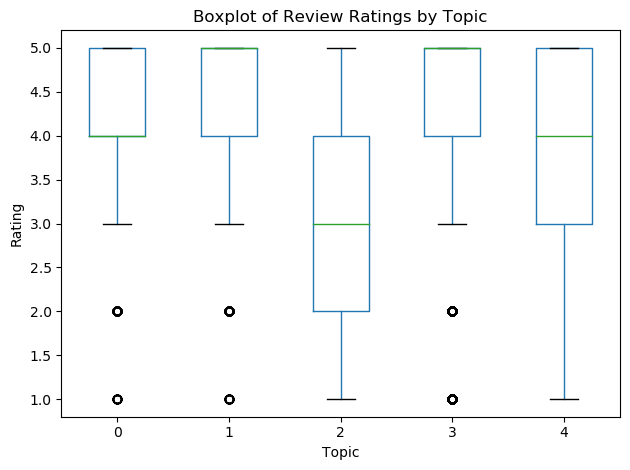

In [ ]:
import matplotlib.pyplot as plt

LDA_data['Rating'] = LDA_data['Rating'].astype(float)
LDA_data['Topic'] = LDA_data['Topic'].astype(int)

plt.figure(figsize=(10, 6))
LDA_data.boxplot(column='Rating', by='Topic', grid=False)
plt.title('Boxplot of Review Ratings by Topic')
plt.suptitle('') # removes pandas automatic subtitle
plt.xlabel('Topic')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

In [ ]:
# See the average rating for each topic
print(LDA_data.groupby('Topic')['Rating'].mean())

# See how many reviews fell into each topic
print(LDA_data['Topic'].value_counts())

Topic
0    3.867453
1    4.437922
2    2.624694
3    3.747328
4    3.912162
Name: Rating, dtype: float64
Topic
1    8296
3    5145
4    3552
2    2041
0    1441
Name: count, dtype: int64


### Vectorization for NMF
### Hyperparameter Stack:
.....

In [ ]:
# Create a dedicated NMF dataframe from your english reviews
nmf_data = reviews_en.copy()

# Ensure the clean_text column exists (joining the lemmatized tokens)
nmf_data['clean_text'] = nmf_data['Tokens'].apply(lambda tokens: ' '.join(tokens))

# Preview the clean data
nmf_data[['Review', 'clean_text']].head()

,Review,clean_text
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice room experience hotel monaco seattle good...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.95,        
    min_df=2,           
    max_features=2000   
    )

dtm_tfidf = tfidf_vectorizer.fit_transform(nmf_data['clean_text'])

In [ ]:
print(dtm_tfidf[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 61 stored elements and shape (1, 2000)>
  Coords	Values
  (0, 1134)	0.3053820750271835
  (0, 844)	0.07321626242476674
  (0, 618)	0.10583556919892535
  (0, 1231)	0.35510129245489136
  (0, 752)	0.07891397508907724
  (0, 750)	0.0541240509776907
  (0, 455)	0.11217046814305294
  (0, 1672)	0.10301360372272345
  (0, 66)	0.15410795960382653
  (0, 89)	0.09567674913615373
  (0, 945)	0.11210533830595351
  (0, 593)	0.10538000158258358
  (0, 1795)	0.09707433971669573
  (0, 29)	0.14346472681244288
  (0, 1327)	0.13453262240391622
  (0, 1460)	0.0825932394644516
  (0, 1883)	0.1491904732594534
  (0, 303)	0.08800236453097438
  (0, 1373)	0.12873678980241446
  (0, 552)	0.10252654568977325
  (0, 979)	0.07721130326695999
  (0, 501)	0.11739722102699501
  (0, 1145)	0.1310294245990769
  (0, 1892)	0.07825713083443392
  (0, 1479)	0.10633695247768392
  :	:
  (0, 1099)	0.09138908483336958
  (0, 1000)	0.14158181759965227
  (0, 517)	0.09324661387748452
  (

In [ ]:
# Initialize the NMF model
nmf_model = NMF(n_components=5, random_state=42, init='nndsvd')

# Fit the model to your Count Vectorized data
nmf_model.fit(dtm_tfidf)

# Get the vocabulary names
nmf_feature_names = tfidf_vectorizer.get_feature_names_out()

# Display the Top 10 words for each NMF topic
for index, topic in enumerate(nmf_model.components_):
    print(f'THE TOP 10 WORDS FOR NMF TOPIC #{index}')
    top_word_indices = topic.argsort()[-10:]
    print([nmf_feature_names[i] for i in top_word_indices])
    print('\n')

THE TOP 10 WORDS FOR NMF TOPIC #0
['wonderful', 'paris', 'recommend', 'excellent', 'best', 'service', 'stayed', 'stay', 'staff', 'hotel']


THE TOP 10 WORDS FOR NMF TOPIC #1
['drink', 'restaurant', 'good', 'people', 'time', 'day', 'pool', 'food', 'beach', 'resort']


THE TOP 10 WORDS FOR NMF TOPIC #2
['bathroom', 'stay', 'day', 'view', 'check', 'desk', 'floor', 'night', 'bed', 'room']


THE TOP 10 WORDS FOR NMF TOPIC #3
['room', 'nice', 'minute', 'clean', 'hotel', 'location', 'station', 'breakfast', 'walk', 'good']


THE TOP 10 WORDS FOR NMF TOPIC #4
['stayed', 'clean', 'room', 'helpful', 'friendly', 'place', 'staff', 'stay', 'location', 'great']




In [ ]:
# Transform the numerical matrix to get topic weights
# This shows how much each document belongs to each of the 5 topics
nmf_topic_results = nmf_model.transform(dtm_tfidf)

# Assign the winning topic index to the dataframe
nmf_data['Topic'] = nmf_topic_results.argmax(axis=1)

# Reorder columns and fix the naming to match your notebook's case-sensitivity
nmf_data = nmf_data[['Review', 'Rating', 'Topic', 'Tokens']]

# Preview results
nmf_data.head()

,Review,Rating,Topic,Tokens
0,nice hotel expensive parking got good deal sta...,4,2,"[nice, hotel, expensive, parking, got, good, d..."
1,ok nothing special charge diamond member hilto...,2,2,"[ok, nothing, special, charge, diamond, member..."
2,nice rooms not 4* experience hotel monaco seat...,3,2,"[nice, room, experience, hotel, monaco, seattl..."
3,"unique, great stay, wonderful time hotel monac...",5,4,"[unique, great, stay, wonderful, time, hotel, ..."
4,"great stay great stay, went seahawk game aweso...",5,2,"[great, stay, great, stay, went, seahawk, game..."


In [ ]:
# See the average rating for each topic
print(nmf_data.groupby('Topic')['Rating'].mean())

# See how many reviews fell into each topic
print(nmf_data['Topic'].value_counts()) 

Topic
0    4.320181
1    3.880371
2    3.202498
3    4.172845
4    4.545763
Name: Rating, dtype: float64
Topic
2    5284
3    4235
1    4096
4    3540
0    3320
Name: count, dtype: int64
